In [1]:
import torch
print(torch.__version__)
print(torch.cuda.is_available()) 
# cuda - compute unified device architecture, a parallel computing platform and application programming interface (API) model created by Nvidia. It allows software developers to use a CUDA-enabled graphics processing unit (GPU) for general purpose processing - an approach known as GPGPU (General-Purpose computing on Graphics Processing Units).


2.11.0+cpu
False


In [2]:
import torch 
import torch.nn as nn # for building neural networks

import torch.optim as optim # for optimization algorithms like SGD, Adam, etc.
from torchvision import datasets , transforms # for data loading and transformations

from torch.utils.data import DataLoader # for creating data loaders >> to iterate through datasets in batches


import matplotlib.pyplot as plt 
import numpy as np 

from sklearn.metrics import confusion_matrix , ConfusionMatrixDisplay


In [3]:
train_dataset = datasets.MNIST("./data", train = True , transform = transforms.ToTensor() , download = True)
test_datasets = datasets.MNIST("./data", train = False , transform = transforms.ToTensor() , download = True)

In [4]:
test_datasets = datasets.MNIST("./data", train = False , transform = transforms.ToTensor() , download = True)

In [5]:
pwd

'c:\\Users\\Lenovo\\OneDrive\\Apps\\Desktop\\Deep Learning\\04_Pytorch'

In [6]:
# dataloader for batching 

train_loader = DataLoader(train_dataset ,batch_size = 32 , shuffle = True)
test_loader = DataLoader(test_datasets ,batch_size = 32 , shuffle = False)

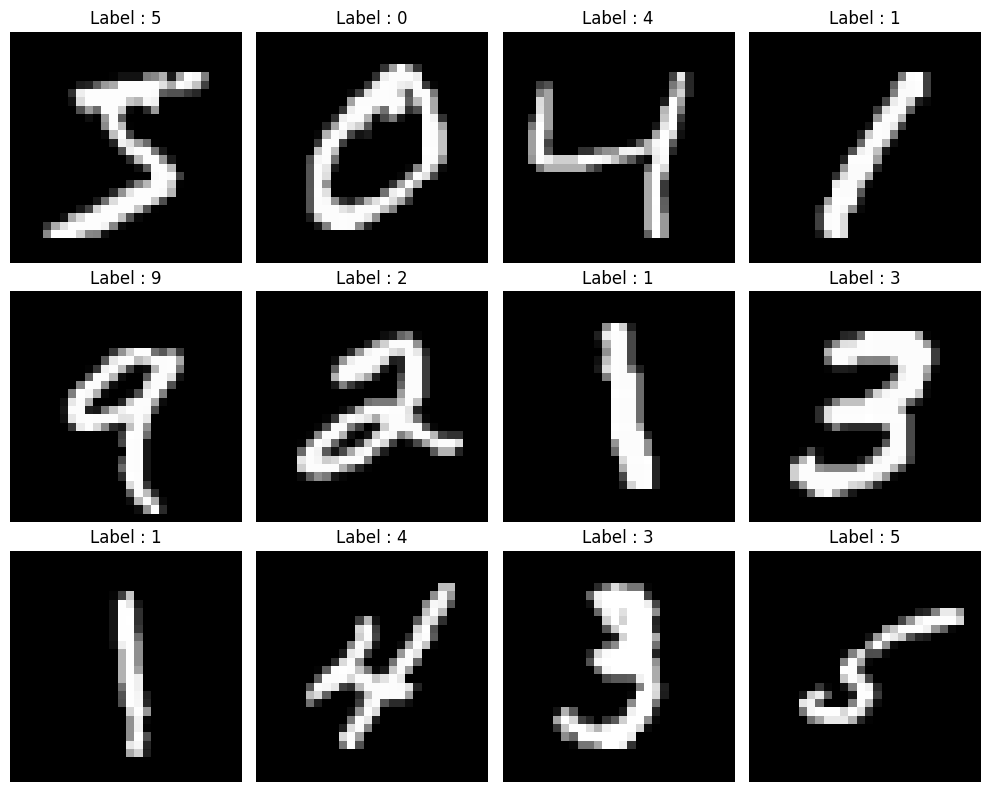

In [7]:
fig,axes = plt.subplots(3,4 , figsize = (10,8))

for i , ax in enumerate(axes.flatten()):
    img , label = train_dataset[i]
    ax.imshow(img.squeeze() , cmap = "gray")
    ax.set_title(f"Label : {label}")
    ax.axis("off")

plt.tight_layout()

In [8]:
model = nn.Sequential(
    nn.Linear(784 , 64),
    nn.ReLU(),
    nn.Linear(64 , 128),
    nn.ReLU(),
    nn.Linear(128 , 10)
).to(device="cuda" if torch.cuda.is_available() else "cpu")

In [9]:
model

Sequential(
  (0): Linear(in_features=784, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=128, bias=True)
  (3): ReLU()
  (4): Linear(in_features=128, out_features=10, bias=True)
)

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters() , lr = 0.001)


In [13]:
num_epochs = 15
train_losses = []
train_accuracies = []

for epoch in range(num_epochs):
    model.train() # set the model to training mode
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device="cuda" if torch.cuda.is_available() else "cpu"), labels.to(device="cuda" if torch.cuda.is_available() else "cpu")

        # forward loss 
        outputs = model(images.view(-1, 28*28)) # flatten the images
        loss = criterion(outputs, labels)

        # backward propagation and optimizer step 
        optimizer.zero_grad() # clear the gradients
        loss.backward() # compute the gradients
        optimizer.step() # update the weights


        running_loss += loss.item()
        # calculate accuracy
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    avg_loss = running_loss / len(train_loader)
    accuracy = correct / total
    train_losses.append(avg_loss)
    train_accuracies.append(accuracy)

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}, Accuracy: {accuracy:.4f}")

Epoch [1/15], Loss: 0.3095, Accuracy: 0.9086
Epoch [2/15], Loss: 0.1332, Accuracy: 0.9594
Epoch [3/15], Loss: 0.0941, Accuracy: 0.9711
Epoch [4/15], Loss: 0.0741, Accuracy: 0.9766
Epoch [5/15], Loss: 0.0600, Accuracy: 0.9812
Epoch [6/15], Loss: 0.0497, Accuracy: 0.9839
Epoch [7/15], Loss: 0.0420, Accuracy: 0.9861
Epoch [8/15], Loss: 0.0364, Accuracy: 0.9879
Epoch [9/15], Loss: 0.0301, Accuracy: 0.9901
Epoch [10/15], Loss: 0.0266, Accuracy: 0.9915
Epoch [11/15], Loss: 0.0223, Accuracy: 0.9925
Epoch [12/15], Loss: 0.0252, Accuracy: 0.9908
Epoch [13/15], Loss: 0.0183, Accuracy: 0.9937
Epoch [14/15], Loss: 0.0192, Accuracy: 0.9939
Epoch [15/15], Loss: 0.0153, Accuracy: 0.9946


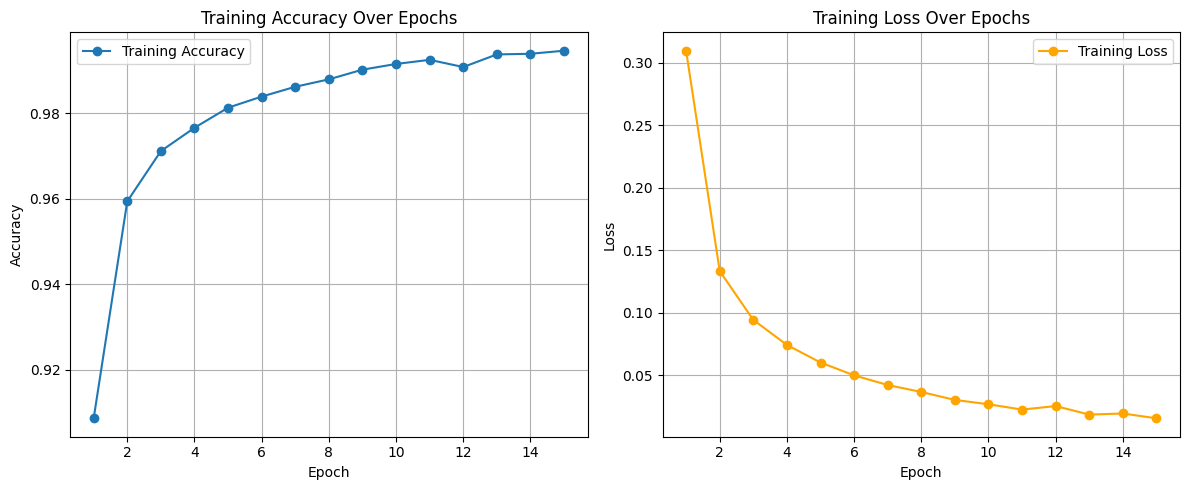

In [14]:
plt.figure(figsize=(12, 5))

# Accuracy curve
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), train_accuracies, marker='o', label='Training Accuracy')
plt.title('Training Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

# Loss curve
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), train_losses, marker='o', color='orange', label='Training Loss')
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [16]:
model.eval()  # Set model to evaluation mode
correct = 0
total = 0

all_labels = []
all_preds = []

with torch.no_grad():  # Disable gradient tracking for evaluation
    for images, labels in test_loader:
        images, labels = images.to(device="cuda" if torch.cuda.is_available() else "cpu"), labels.to(device="cuda" if torch.cuda.is_available() else "cpu")
        outputs = model(images.view(-1, 28*28))
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())

test_accuracy = correct / total
print(f"✅ Test Accuracy: {test_accuracy:.4f}")

✅ Test Accuracy: 0.9784


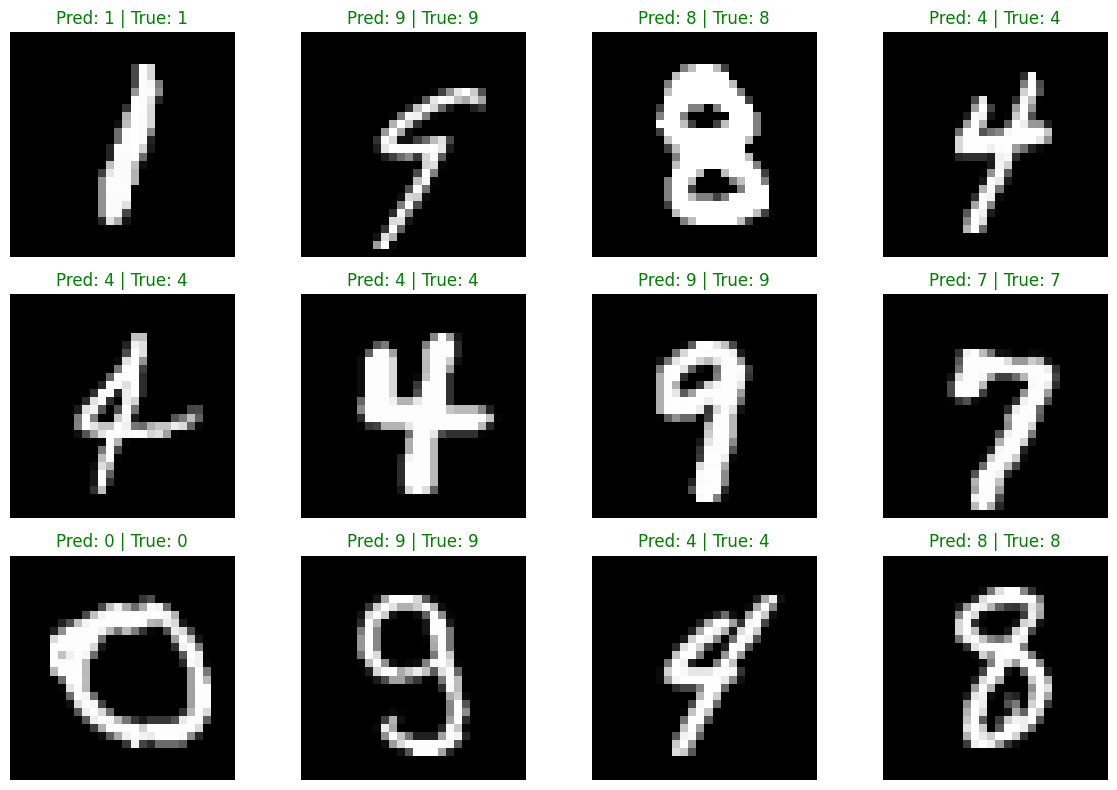

In [18]:
plt.figure(figsize=(12, 8))
for i, idx in enumerate(np.random.choice(len(test_datasets), 12, replace=False)):
    img, label = test_datasets[idx]
    img_flat = img.to(device="cuda" if torch.cuda.is_available() else "cpu")

    with torch.no_grad():
        output = model(img_flat.view(1, -1))
        pred = output.argmax(dim=1).item()

    plt.subplot(3, 4, i+1)
    plt.imshow(img.view(28, 28), cmap='gray')
    color = 'green' if pred == label else 'red'
    plt.title(f"Pred: {pred} | True: {label}", color=color)
    plt.axis('off')
plt.tight_layout()
plt.show()

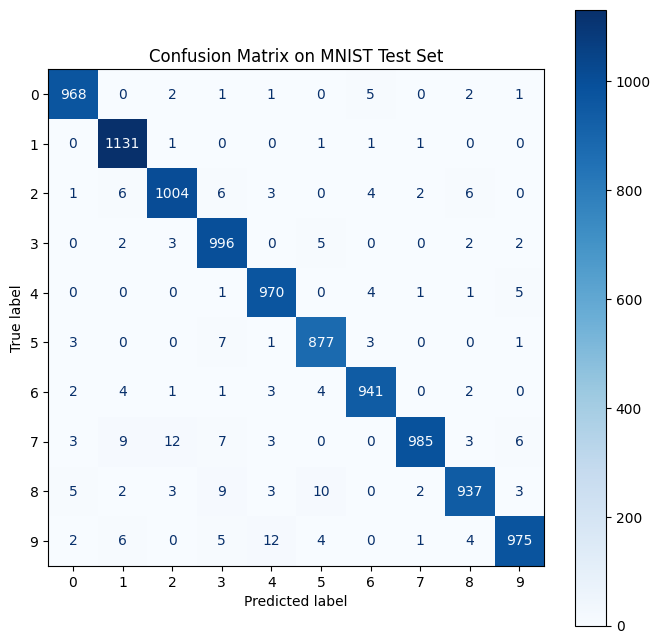

In [19]:
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap='Blues')
plt.title("Confusion Matrix on MNIST Test Set")
plt.show()